In [ ]:
print('Running imports...')
import os
from captum.attr import IntegratedGradients

os.environ["MKL_THREADING_LAYER"] = "GNU"

import torch # long
from lightning.pytorch import seed_everything
from torch import nn 

import xarray as xr
from tqdm import tqdm
import pandas as pd
import numpy as np 
import seaborn.objects as so
import argparse
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import seaborn as sns
import sys 
sys.path.append('/home/rogui7909/code/predict_rain_norway/predict_rain')
from ml_module_rain.models.trained_models import load_trained_model

Running imports...


In [ ]:
run_id='dpvqf6k0'
samples_to_attribute='all'
final_ds = xr.open_dataset(f"/Data/gfi/users/rogui7909/data/NN_outputs/attributions/{run_id}_attributions_{samples_to_attribute}.nc")
final_ds['fields'] = final_ds.attributions/final_ds.sensitivity
final_ds['rain'] = dataloader.ds_val.rain

In [ ]:
extreme_ds = final_ds.where(final_ds.prediction==2, drop=True).squeeze()
no_extreme_ds = final_ds.where(final_ds.prediction==0, drop=True).squeeze()
true_extreme_ds = final_ds.where(final_ds.target==2, drop=True).squeeze()

not_sure = final_ds.where(final_ds.prediction==1, drop=True).squeeze()

(0.0, 200.0)

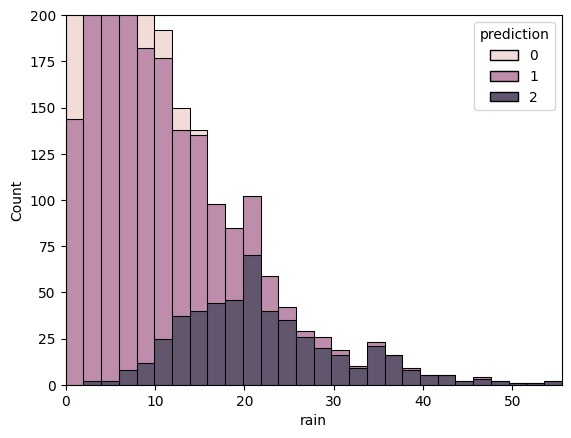

In [ ]:
df_ = final_ds[['rain','prediction']].to_dataframe()

sns.histplot(df_, x='rain', binwidth=2, hue='prediction', multiple='stack')
# plt.yscale('log')
plt.xlim(0,55.5)
plt.ylim(0,200)

In [ ]:
true_extreme_ds.where(true_extreme_ds.prediction==1, drop=True).isel(time=0)

<xarray.Dataset> Size: 985kB
Dimensions:       (var_name: 5, latitude: 90, longitude: 182)
Coordinates:
  * var_name      (var_name) <U4 80B 't850' 'z500' 'v850' 'u850' 'msl'
  * latitude      (latitude) float64 720B 0.0 1.0 2.0 3.0 ... 87.0 88.0 89.0
  * longitude     (longitude) float64 1kB -128.0 -127.0 -126.0 ... 52.0 53.0
    time          datetime64[ns] 8B 1999-07-21
    timestep      int64 8B 0
    quantile      float64 8B 0.9
Data variables:
    attributions  (var_name, latitude, longitude) float32 328kB -3.976e-06 .....
    sensitivity   (var_name, latitude, longitude) float32 328kB 3.145e-05 ......
    prediction    float64 8B 1.0
    target        float64 8B 2.0
    fields        (var_name, latitude, longitude) float32 328kB -0.1264 ... 1...
    rain          float64 8B 20.71

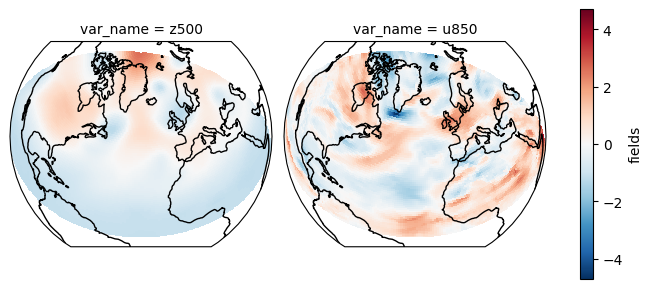

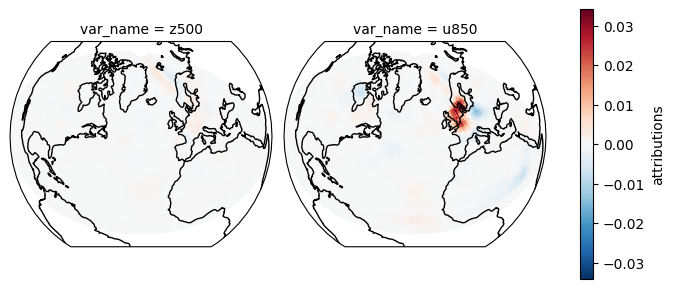

In [ ]:
ds_ = true_extreme_ds.where(true_extreme_ds.prediction==1, drop=True).isel(time=0)
plot =(ds_.fields - ds_.fields.mean(['longitude','latitude'])).plot(col='var_name', subplot_kws = dict(projection=ccrs.Orthographic(-30,50)), transform=ccrs.PlateCarree())
for ax in plot.axs.flatten():
    ax.coastlines()

plot =(ds_.attributions).rolling(longitude=5,latitude=5, center=True).mean().plot(col='var_name', subplot_kws = dict(projection=ccrs.Orthographic(-30,50)), transform=ccrs.PlateCarree(),)
for ax in plot.axs.flatten():
    ax.coastlines()

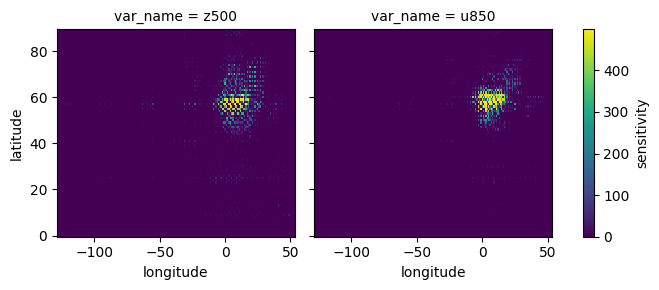

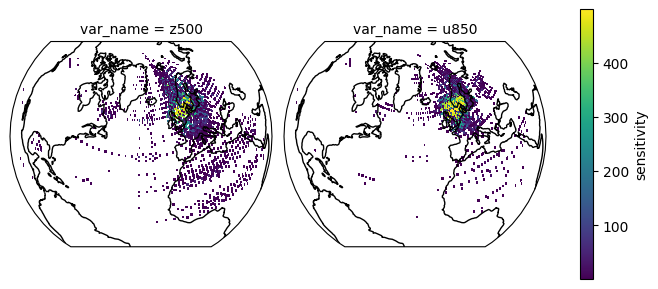

In [ ]:
ranks = (extreme_ds.sensitivity).stack(space=['latitude','longitude']).rank('space',pct=True).unstack()
(ranks>0.99).sum('time').plot(col='var_name')

plot =((ranks>0.99).sum('time').where((ranks>0.99).sum('time')>0)).plot(col='var_name', subplot_kws = dict(projection=ccrs.Orthographic(-30,50)), transform=ccrs.PlateCarree(),)
for ax in plot.axs.flatten():
    ax.coastlines()

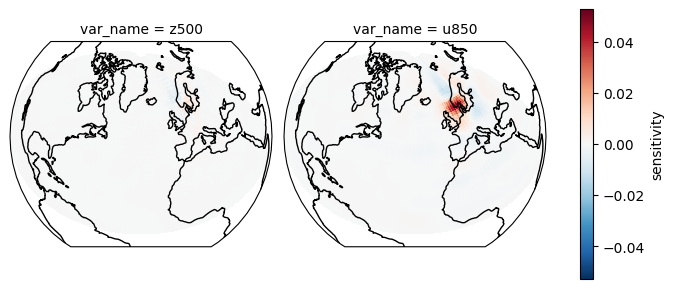

In [ ]:
plot =(extreme_ds.sensitivity).mean('time').rolling(longitude=5,latitude=5, center=True).mean().plot(col='var_name', subplot_kws = dict(projection=ccrs.Orthographic(-30,50)), transform=ccrs.PlateCarree(),)
for ax in plot.axs.flatten():
    ax.coastlines()

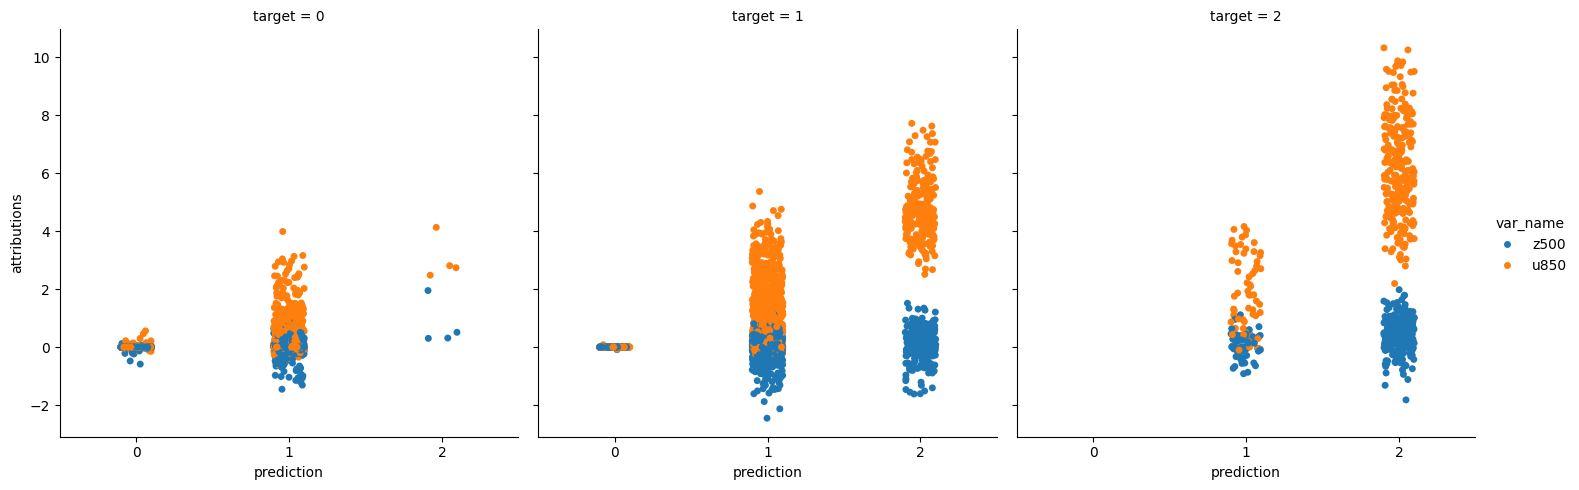

In [ ]:
df_ = final_ds[['attributions','prediction','target']].sum(['longitude','latitude']).to_dataframe().reset_index()

sns.catplot(df_, x='prediction', y='attributions', hue='var_name', col='target')

In [ ]:
ds_.fields - ds_.fields.mean(['longitude','latitude'])

<xarray.DataArray 'fields' (var_name: 5, latitude: 90, longitude: 182)> Size: 328kB
array([[[-1.2958626 , -1.2951496 , -1.2689688 , ..., -1.5417231 ,
         -1.4836185 , -1.4496228 ],
        [-1.2531781 , -1.2292793 , -1.2102104 , ..., -1.5176357 ,
         -1.4905521 , -1.436753  ],
        [-1.2225701 , -1.194088  , -1.190295  , ..., -1.506022  ,
         -1.4827055 , -1.4726161 ],
        ...,
        [ 1.4830412 ,  1.4818786 ,  1.4817103 , ...,  1.1375693 ,
          1.1409296 ,  1.1445197 ],
        [ 1.7279898 ,  1.7277213 ,  1.7272457 , ...,  1.1963819 ,
          1.1953753 ,  1.19465   ],
        [ 1.6327723 ,  1.6338927 ,  1.6348435 , ...,  1.3568064 ,
          1.3550481 ,  1.3533639 ]],

       [[-1.1377888 , -1.139518  , -1.1411794 , ..., -1.2126395 ,
         -1.2150145 , -1.2186258 ],
        [-1.1406164 , -1.1425065 , -1.1439538 , ..., -1.2183667 ,
         -1.2208778 , -1.2226698 ],
        [-1.1456429 , -1.1470158 , -1.1482271 , ..., -1.2252176 ,
         -1.2288902 , -1.2308791 ],
...
        [-0.8481787 , -0.8306398 , -0.81352925, ..., -1.385931  ,
         -1.3855392 , -1.3831754 ],
        [-1.321078  , -1.3232957 , -1.3247328 , ..., -0.6944915 ,
         -0.685169  , -0.6756244 ],
        [-0.8482197 , -0.86108094, -0.8733478 , ..., -0.10046522,
         -0.08721749, -0.07375169]],

       [[ 0.29288256,  0.3015865 ,  0.31066692, ...,  0.34781837,
          0.3164967 ,  0.28655475],
        [ 0.29725367,  0.30425173,  0.31388167, ...,  0.3305251 ,
          0.30387414,  0.27845508],
        [ 0.29877925,  0.303826  ,  0.3106354 , ...,  0.30870306,
          0.28458655,  0.2633145 ],
        ...,
        [ 1.2054174 ,  1.1997699 ,  1.1944057 , ...,  1.6293957 ,
          1.6309881 ,  1.6326575 ],
        [ 1.459917  ,  1.4555639 ,  1.4511353 , ...,  1.7855934 ,
          1.7876908 ,  1.7896792 ],
        [ 1.6804614 ,  1.6783136 ,  1.6762538 , ...,  1.8589004 ,
          1.8601847 ,  1.8615104 ]]], dtype=float32)
Coordinates:
  * var_name   (var_name) <U4 80B 't850' 'z500' 'v850' 'u850' 'msl'
  * latitude   (latitude) float64 720B 0.0 1.0 2.0 3.0 ... 86.0 87.0 88.0 89.0
  * longitude  (longitude) float64 1kB -128.0 -127.0 -126.0 ... 51.0 52.0 53.0
    time       datetime64[ns] 8B 1999-07-21
    timestep   int64 8B 0
    quantile   float64 8B 0.9

In [ ]:
(final_ds.attributions!=0).sum('time')

<xarray.DataArray 'attributions' (timestep: 1, var_name: 2, latitude: 90,
                                  longitude: 182)> Size: 262kB
array([[[[1810, 1810, 1810, ..., 1810, 1810, 1810],
         [1810, 1810, 1810, ..., 1810, 1810, 1810],
         [1810, 1810, 1810, ..., 1810, 1810, 1810],
         ...,
         [1810, 1810, 1810, ..., 1810, 1810, 1810],
         [1810, 1810, 1810, ..., 1810, 1810, 1810],
         [1810, 1810, 1810, ..., 1810, 1810, 1810]],

        [[1810, 1810, 1810, ..., 1810, 1810, 1810],
         [1810, 1810, 1810, ..., 1810, 1810, 1810],
         [1810, 1810, 1810, ..., 1810, 1810, 1810],
         ...,
         [1810, 1810, 1810, ..., 1810, 1810, 1810],
         [1810, 1810, 1810, ..., 1810, 1810, 1810],
         [1810, 1810, 1810, ..., 1810, 1810, 1810]]]])
Coordinates:
  * var_name   (var_name) <U4 32B 'z500' 'u850'
  * latitude   (latitude) float64 720B 0.0 1.0 2.0 3.0 ... 86.0 87.0 88.0 89.0
  * longitude  (longitude) float64 1kB -128.0 -127.0 -126.0 ... 51.0 52.0 53.0
  * timestep   (timestep) int64 8B 0
    quantile   float64 8B 0.9

In [ ]:
final_ds.attributions.count('time')

<xarray.DataArray 'attributions' (timestep: 1, var_name: 5, latitude: 90,
                                  longitude: 182)> Size: 655kB
array([[[[4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         ...,
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608]],

        [[4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         ...,
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608]],

        [[4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         ...,
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608]],

        [[4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         ...,
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608]],

        [[4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         ...,
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608],
         [4608, 4608, 4608, ..., 4608, 4608, 4608]]]])
Coordinates:
  * var_name   (var_name) <U4 80B 't850' 'z500' 'v850' 'u850' 'msl'
  * latitude   (latitude) float64 720B 0.0 1.0 2.0 3.0 ... 86.0 87.0 88.0 89.0
  * longitude  (longitude) float64 1kB -128.0 -127.0 -126.0 ... 51.0 52.0 53.0
  * timestep   (timestep) int64 8B 0
    quantile   float64 8B 0.9

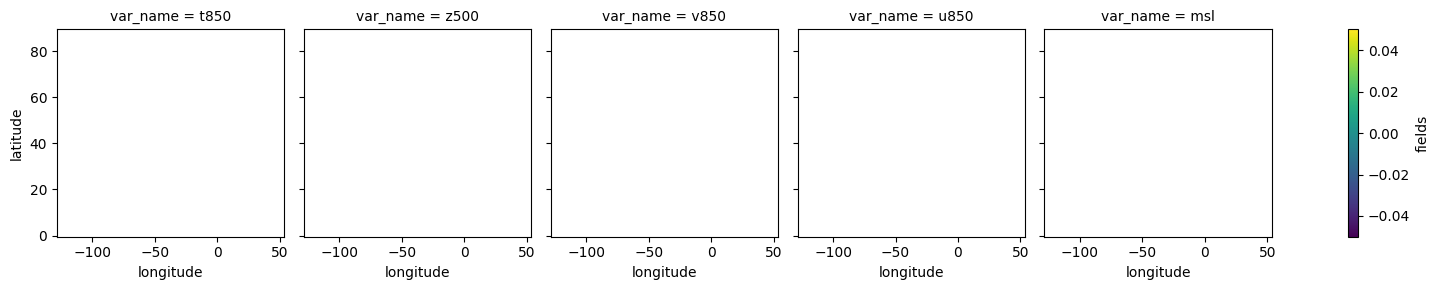

In [ ]:
true_extreme_ds.where(true_extreme_ds.prediction==0, drop=True).fields.plot(col='var_name')

In [ ]:
pd.cut(rain, bins)
bins

ValueError: bins must increase monotonically.

In [ ]:
rain = final_ds.rain.squeeze()
bins=np.array([0]+list(rain.where(rain>1).quantile([0.5,0.9]).values)+[1000])
count = rain.groupby_bins(rain, bins).count()
(1/count)/((1/count).sum())

<xarray.DataArray 'rain' (rain_bins: 3)> Size: 24B
array([0.07584753, 0.18518777, 0.7389647 ])
Coordinates:
    timestep   int64 8B 0
    quantile   float64 8B 0.9
  * rain_bins  (rain_bins) interval[float64, right] 48B (0.0, 6.136] ... (20....

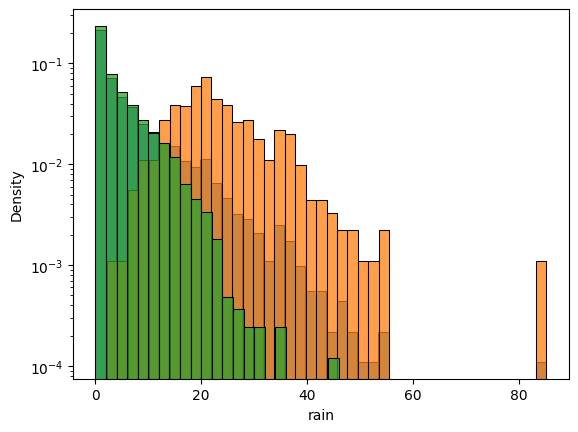

In [ ]:
sns.histplot(final_ds.rain.to_series(),binwidth=2, stat='density')

sns.histplot(extreme_ds.rain.to_series(),binwidth=2, stat='density')
sns.histplot(no_extreme_ds.rain.to_series(),binwidth=2, stat='density')

# extreme_ds.rain.to_series().plot.hist(bins=np.arange(0,100,1))
plt.yscale('log')

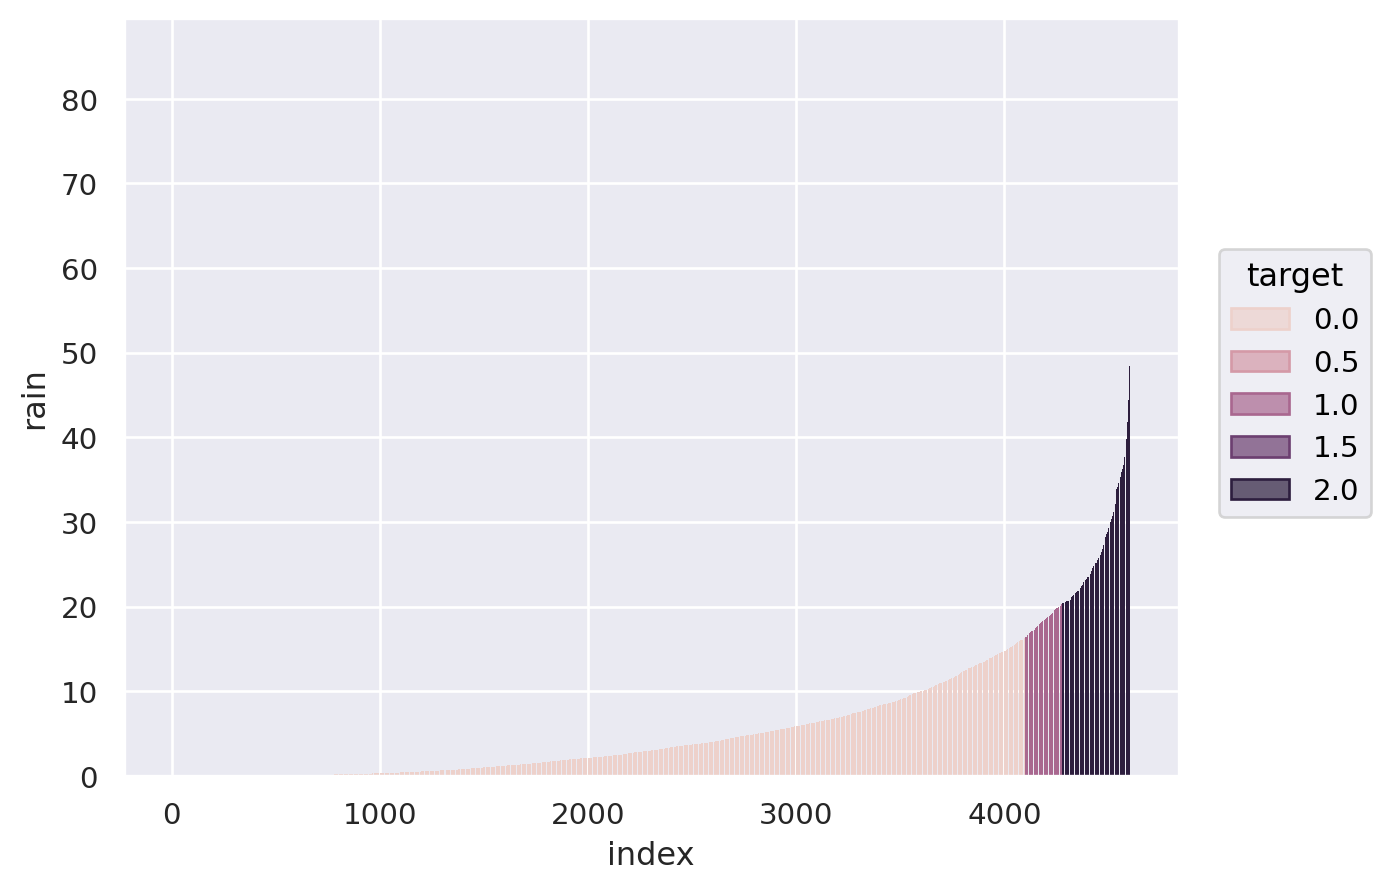

In [ ]:
df_ = final_ds[['rain','target']].to_dataframe().sort_values('rain').reset_index().reset_index()
(so.Plot(df_, x='index', y='rain', color='target')
 .add(so.Bar()))

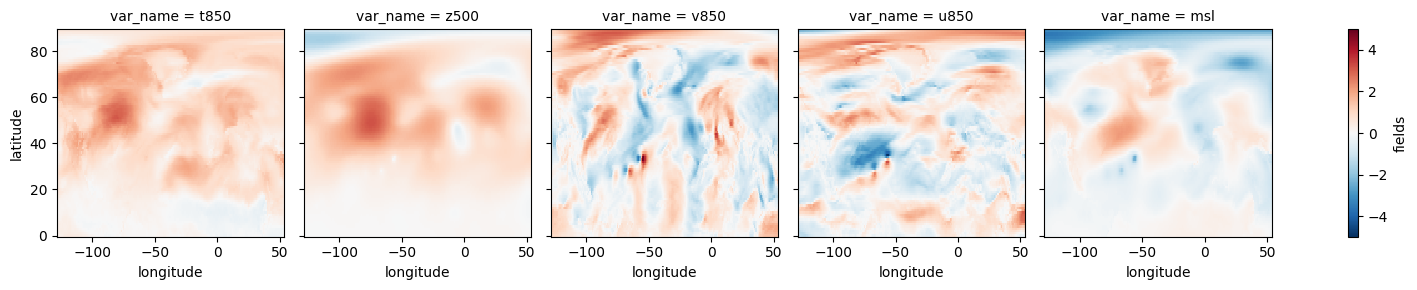

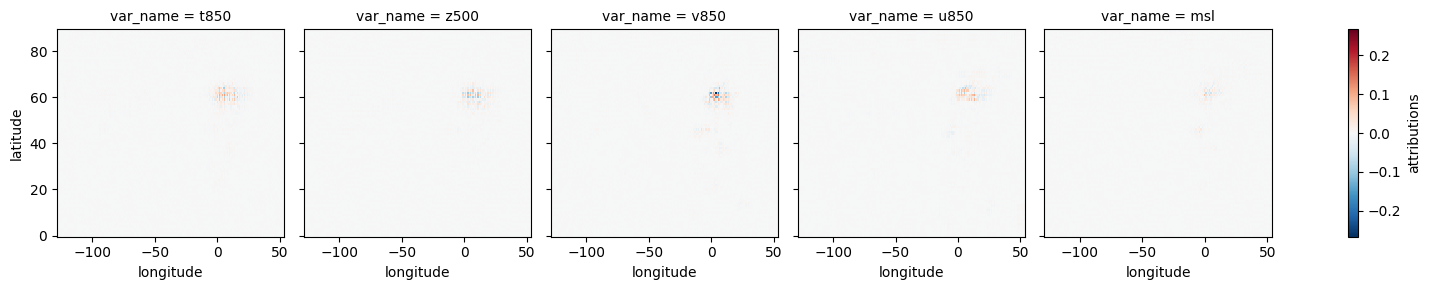

In [ ]:
extreme_ds.fields.sel(time='2005-09-06').plot(col='var_name')


extreme_ds.attributions.sel(time='2005-09-06').plot(col='var_name')

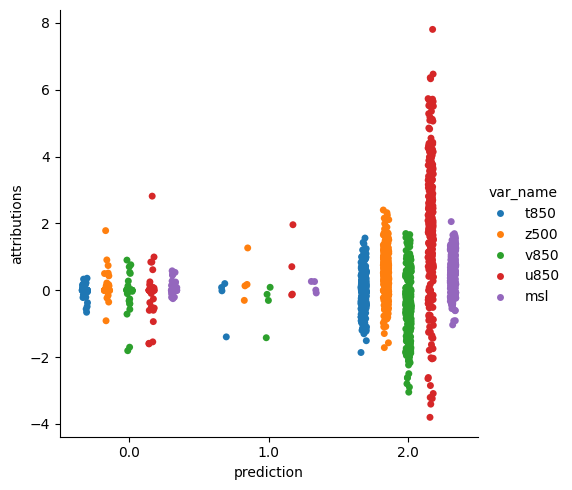

In [ ]:
df = extreme_ds[['attributions','prediction']].sum(['longitude','latitude']).to_dataframe()

sns.catplot(df, x='prediction', y='attributions', hue='var_name', dodge=True,)


In [ ]:
df = 6-extreme_ds['attributions'].sum(['longitude','latitude']).to_series().unstack().rank(axis=1)
pd.DataFrame([df[k].value_counts() for k in df.columns], index=df.columns).sort_index(axis=1)

,1.0,2.0,3.0,4.0,5.0
var_name,,,,,
t850,6,58,76,117,73
z500,35,124,85,69,17
v850,23,19,62,74,152
u850,208,14,42,13,53
msl,26,83,193,25,3


In [ ]:
df[df.columns[0]].value_counts()

t850
2.0    117
3.0     76
1.0     73
4.0     58
5.0      6
Name: count, dtype: int64

In [ ]:
df

attributions  prediction  timestep  quantile
time       var_name                                              
1999-07-21 t850          0.000000         0.0         0       0.9
           z500          0.000000         0.0         0       0.9
           v850          0.000000         0.0         0       0.9
           u850          0.000000         0.0         0       0.9
           msl           0.000000         0.0         0       0.9
...                           ...         ...       ...       ...
2012-01-11 t850         -0.364318         2.0         0       0.9
           z500          0.736218         2.0         0       0.9
           v850         -0.644173         2.0         0       0.9
           u850          3.333887         2.0         0       0.9
           msl           0.508683         2.0         0       0.9

[1650 rows x 4 columns]

/tmp/ipykernel_2542229/3920624961.py:12: RuntimeWarning: invalid value encountered in scalar divide
  recall = TP/binary.sum()
/tmp/ipykernel_2542229/3920624961.py:12: RuntimeWarning: invalid value encountered in scalar divide
  recall = TP/binary.sum()
/tmp/ipykernel_2542229/3920624961.py:12: RuntimeWarning: invalid value encountered in scalar divide
  recall = TP/binary.sum()
/tmp/ipykernel_2542229/3920624961.py:12: RuntimeWarning: invalid value encountered in scalar divide
  recall = TP/binary.sum()
/tmp/ipykernel_2542229/3920624961.py:12: RuntimeWarning: invalid value encountered in scalar divide
  recall = TP/binary.sum()
/tmp/ipykernel_2542229/3920624961.py:12: RuntimeWarning: invalid value encountered in scalar divide
  recall = TP/binary.sum()
/tmp/ipykernel_2542229/3920624961.py:12: RuntimeWarning: invalid value encountered in scalar divide
  recall = TP/binary.sum()
/tmp/ipykernel_2542229/3920624961.py:12: RuntimeWarning: invalid value encountered in scalar divide
  recall = 

(0.5, 1.05)

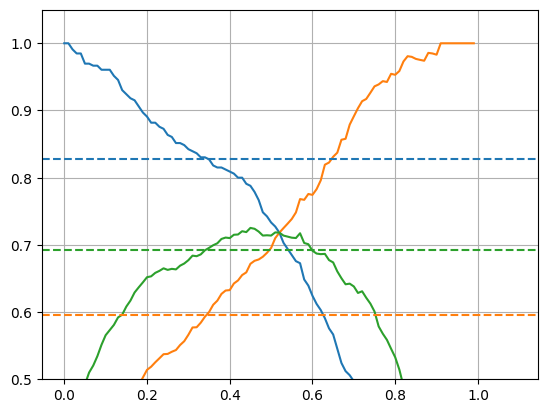

In [ ]:
from scipy.special import softmax
df = pd.DataFrame(pd.DataFrame(softmax(probas.squeeze(), axis=1), columns=['non','buffer','extreme']))
df.index = series_targets.index
limits = np.arange(0,1.1,.01)
f1s = []
precisions=[]
recalls = []
for limit in limits:
    binary = 1*(df.extreme > limit)
    TP = (binary & (series_targets==2)).sum()
    precision = TP/(series_targets==2).sum()
    recall = TP/binary.sum()
    f1 = 2*precision*recall/(precision+recall)
    f1s.append(f1)
    recalls.append(recall)
    precisions.append(precision)
plt.plot(limits, precisions)
plt.plot(limits, recalls)
plt.plot(limits, f1s)

TP = ((series_predictions==2) & (series_targets==2)).sum()
precision = TP/(series_targets==2).sum()
recall = TP/(series_predictions==2).sum()
f1 = 2*precision*recall/(precision+recall)

plt.axhline(precision, ls='--', color='C0')
plt.axhline(recall, ls='--', color='C1')
plt.axhline(f1, ls='--', color='C2')

plt.grid()
plt.ylim(0.5,None)

DatetimeIndex(['2004-02-18', '2006-01-25', '2010-01-21', '2001-02-02',
               '2006-02-20', '2005-12-26', '2002-02-20', '2006-03-07',
               '2000-05-11', '2002-11-10',
               ...
               '2008-02-21', '2000-03-06', '2011-12-26', '2000-01-08',
               '2003-01-15', '2005-11-14', '2008-01-25', '2007-01-15',
               '2011-12-25', '2005-01-12'],
              dtype='datetime64[ns]', name='time', length=4608, freq=None)

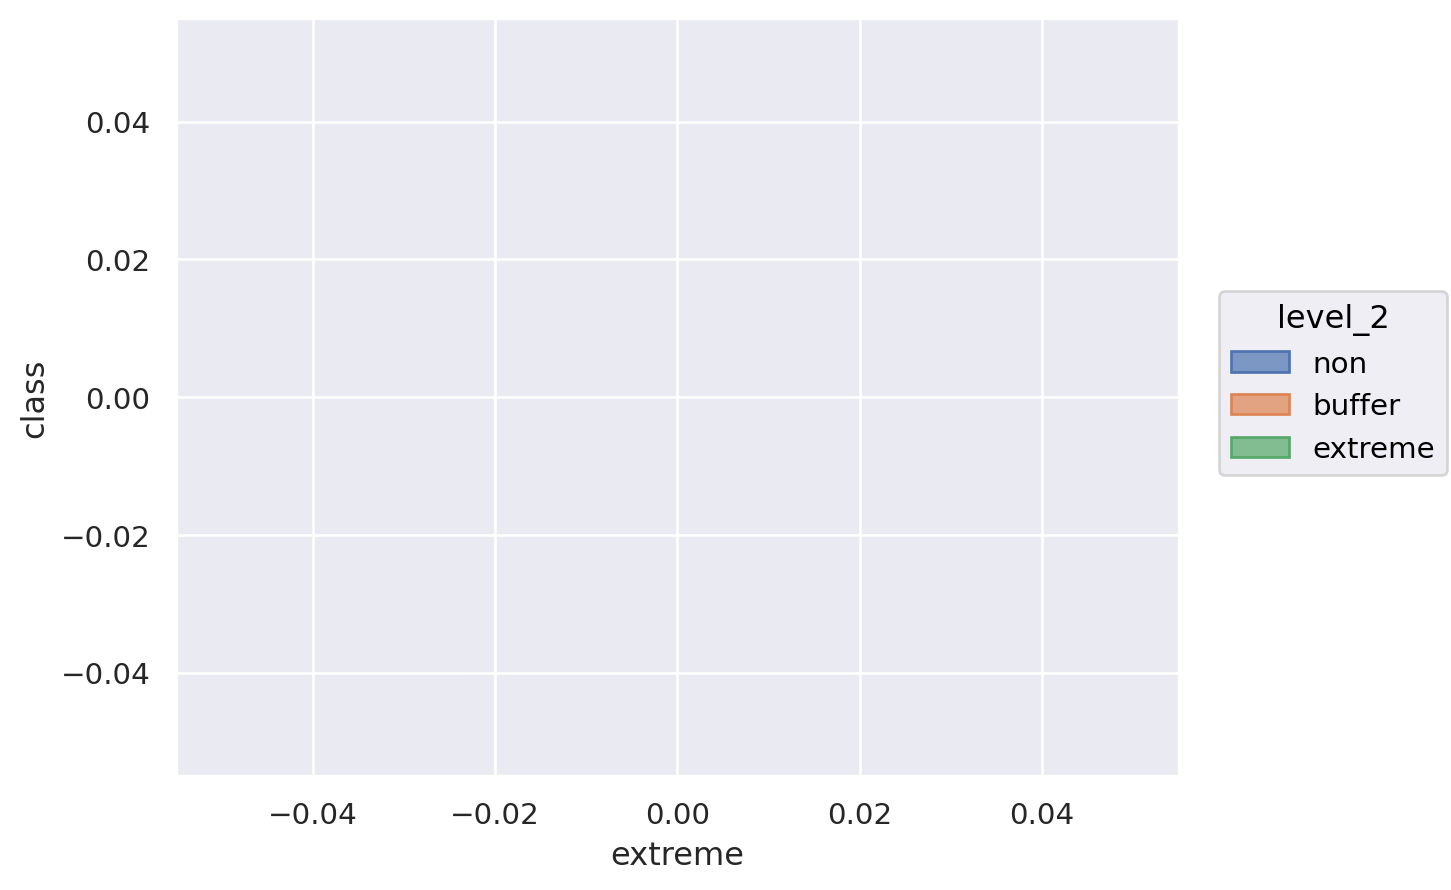

In [ ]:
import seaborn.objects as so

# so.plot
df_ = df#.stack().rename('class').reset_index()
df_.extreme.rank()
(so.Plot(df.stack().rename('class').reset_index(),y='class', color='level_2')
        .add(so.Bar(), so.Stack(), x=df_.extreme.rank())
        .scale(#x=so.Nominal(order=df.sort_values('extreme').index.get_level_values(0)),
               level_2 = so.Nominal(['extreme','buffer','no'])) 
)

In [ ]:
dataloader.config['num_classes']

{'batch_size': 512,
 'learning_rate': 0.0001,
 'lr_scheduler': 'step',
 'num_epochs': 100,
 'loss_function': 'crossentropy',
 'activation_function': 'ReLU',
 'file_name_data_out': '/Data/gfi/users/rogui7909/data/ERA5/precipitation/pr_era5_daily_westnorway_1940-2024.nc',
 'type_prediction': 'three_classes_grey_zone',
 'quantile_extreme': 0.9,
 'quantile_extreme_based_on_rainy_days': True,
 'num_timesteps_predicted': 1,
 'season': 'all',
 'augment_training_with_noise': False,
 'num_noisy_samples': 0,
 'augment_noise_amplitude': 0.5,
 'file_name_data_in': '/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024.zarr',
 'inputs': 't850 z500 v850 u850 msl',
 'spatial_extent': [-128, 53, 0, 90],
 'use_skip_connections': True,
 'CNN_layer_module': 'doubleconv',
 'num_conv_layer': 7,
 'size_conv_kernel': 3,
 'conv1_kernel_number': 16,
 'factor_increase_kernels_per_conv_layer': 2,
 'dropout_CNN': 0.4,
 'batch_norm_CNN': True,
 'MLP_hidden_layers_neuron_number': [128

In [ ]:
df_['rank'] = df_.extreme.rank()
df_.reset_index().pivot(index=['time'], columns = ['non','buffer','extreme'])

timestep                                                        \
non        0.798230 0.993840 0.986842 0.795234 0.976519 0.996418 0.995432   
buffer     0.129332 0.004694 0.009740 0.131731 0.017133 0.002832 0.003510   
extreme    0.072438 0.001466 0.003418 0.073035 0.006348 0.000751 0.001058   
time                                                                        
1999-07-02      0.0      NaN      NaN      NaN      NaN      NaN      NaN   
1999-07-03      NaN      0.0      NaN      NaN      NaN      NaN      NaN   
1999-07-04      NaN      NaN      0.0      NaN      NaN      NaN      NaN   
1999-07-05      NaN      NaN      NaN      0.0      NaN      NaN      NaN   
1999-07-06      NaN      NaN      NaN      NaN      0.0      NaN      NaN   
...             ...      ...      ...      ...      ...      ...      ...   
2012-02-07      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
2012-02-08      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
2012-02-09      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
2012-02-10      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
2012-02-11      NaN      NaN      NaN      NaN      NaN      NaN      NaN   

                                       ...     rank                    \
non        0.998919 0.992986 0.999459  ... 0.998553 0.999110 0.999646   
buffer     0.000885 0.005439 0.000452  ... 0.001194 0.000735 0.000302   
extreme    0.000197 0.001575 0.000089  ... 0.000254 0.000155 0.000052   
time                                   ...                              
1999-07-02      NaN      NaN      NaN  ...      NaN      NaN      NaN   
1999-07-03      NaN      NaN      NaN  ...      NaN      NaN      NaN   
1999-07-04      NaN      NaN      NaN  ...      NaN      NaN      NaN   
1999-07-05      NaN      NaN      NaN  ...      NaN      NaN      NaN   
1999-07-06      NaN      NaN      NaN  ...      NaN      NaN      NaN   
...             ...      ...      ...  ...      ...      ...      ...   
2012-02-07      NaN      NaN      NaN  ...      NaN      NaN      NaN   
2012-02-08      NaN      NaN      NaN  ...      NaN      NaN      NaN   
2012-02-09      NaN      NaN      NaN  ...      NaN      NaN      NaN   
2012-02-10      NaN      NaN      NaN  ...      NaN      NaN      NaN   
2012-02-11      NaN      NaN      NaN  ...      NaN      NaN      NaN   

                                                                           
non        0.596429 0.999862 0.999972 0.998544 0.972424 0.997915 0.997795  
buffer     0.246743 0.000119 0.000025 0.001175 0.019653 0.001647 0.001745  
extreme    0.156828 0.000020 0.000003 0.000281 0.007924 0.000438 0.000460  
time                                                                       
1999-07-02      NaN      NaN      NaN      NaN      NaN      NaN      NaN  
1999-07-03      NaN      NaN      NaN      NaN      NaN      NaN      NaN  
1999-07-04      NaN      NaN      NaN      NaN      NaN      NaN      NaN  
1999-07-05      NaN      NaN      NaN      NaN      NaN      NaN      NaN  
1999-07-06      NaN      NaN      NaN      NaN      NaN      NaN      NaN  
...             ...      ...      ...      ...      ...      ...      ...  
2012-02-07      NaN      NaN    174.0      NaN      NaN      NaN      NaN  
2012-02-08      NaN      NaN      NaN   1772.0      NaN      NaN      NaN  
2012-02-09      NaN      NaN      NaN      NaN   3118.0      NaN      NaN  
2012-02-10      NaN      NaN      NaN      NaN      NaN   1974.0      NaN  
2012-02-11      NaN      NaN      NaN      NaN      NaN      NaN   1993.0  

[4608 rows x 9216 columns]

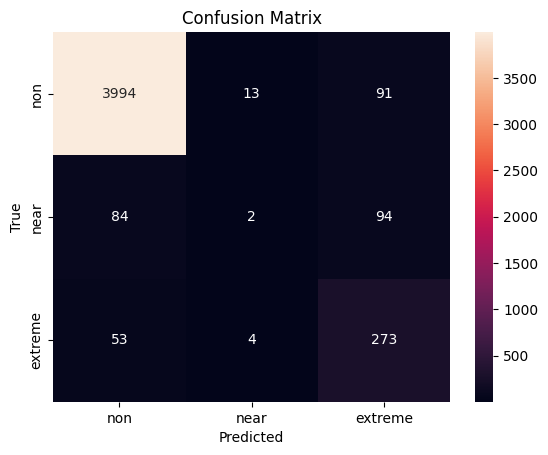

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(series_targets, series_predictions)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=['non', 'near', 'extreme'], yticklabels=['non', 'near', 'extreme'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Collapse to binary
extreme_true = (series_targets == 2)
extreme_pred = (series_predictions == 2)

precision = precision_score(extreme_true, extreme_pred)
recall = recall_score(extreme_true, extreme_pred)
f1 = f1_score(extreme_true, extreme_pred)

f1

0.6928934010152284

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(series_targets, series_predictions, target_names=['non-extreme', 'near-extreme', 'extreme']))


              precision    recall  f1-score   support

 non-extreme       0.97      0.97      0.97      4098
near-extreme       0.11      0.01      0.02       180
     extreme       0.60      0.83      0.69       330

    accuracy                           0.93      4608
   macro avg       0.56      0.60      0.56      4608
weighted avg       0.91      0.93      0.91      4608



In [ ]:
all_targets = []
all_probas = []
for batch in tqdm(dataloader.train_loader):
    x, y = batch
    lightning_model.eval()
    with torch.no_grad():
        all_probas.append(lightning_model(x))
    all_targets.append(y)
probas = torch.cat(all_probas).view(-1, 1, 3)
targets = torch.cat(all_targets).cpu().numpy()
preds = torch.argmax(probas, dim=2).cpu().numpy() 
probas = probas.cpu().numpy()

ds_aligned = dataloader.ds_train.isel(time=range(targets.shape[0]))
preds_da = xr.DataArray(preds, dims=['time','timestep'], coords =ds_aligned.targets.coords)
ds_aligned ['predictions'] = preds_da


series_targets = ds_aligned.targets.to_series()
series_predictions = ds_aligned.predictions.to_series()

all_predictions_train = pd.DataFrame(dict(predictions=series_predictions, targets=series_targets)).reset_index()

In [ ]:

ds_aligned = dataloader.ds_train.isel(time=range(targets.shape[0]))
preds_da = xr.DataArray(preds, dims=['time','timestep'], coords =ds_aligned.targets.coords)
ds_aligned ['predictions'] = preds_da


series_targets = ds_aligned.targets.to_series()
series_predictions = ds_aligned.predictions.to_series()

all_predictions_train = pd.DataFrame(dict(predictions=series_predictions, targets=series_targets)).reset_index()

In [ ]:
TP_train = all_predictions_train.query("predictions==targets & targets==2").targets.count()
precision_train = TP_train/all_predictions_train.query("predictions==2").targets.count()
recall_train = TP_train/all_predictions_train.query("targets==2").targets.count()
F1_train = 2*precision_train*recall_train/(precision_train+recall_train)

TP_test = all_predictions.query("predictions==targets & targets==2").targets.count()
precision_test = TP_test/all_predictions.query("predictions==2").targets.count()
recall_test = TP_test/all_predictions.query("targets==2").targets.count()
F1_test = 2*precision_test*recall_test/(precision_test+recall_test)

F1_test, F1_train

(np.float64(0.6928934010152284), np.float64(0.6940720881739649))

In [ ]:
print(recall_test, recall_train)
print(precision_test, precision_train)


0.8272727272727273 0.8812405446293494
0.5960698689956332 0.5724815724815725


<Axes: xlabel='targets', ylabel='predictions'>

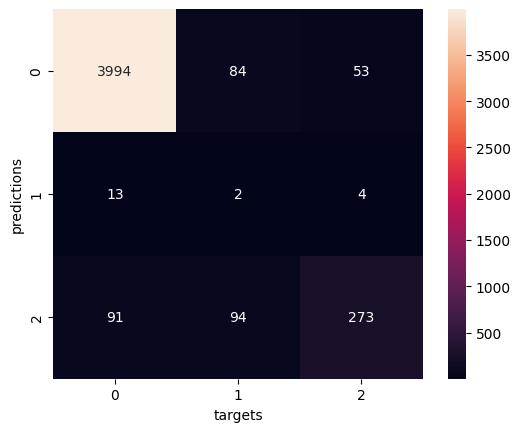

In [ ]:
sns.heatmap(all_predictions.groupby(['predictions','targets']).timestep.count().unstack(), annot=True, square=True, fmt='d')

<Axes: xlabel='targets', ylabel='predictions'>

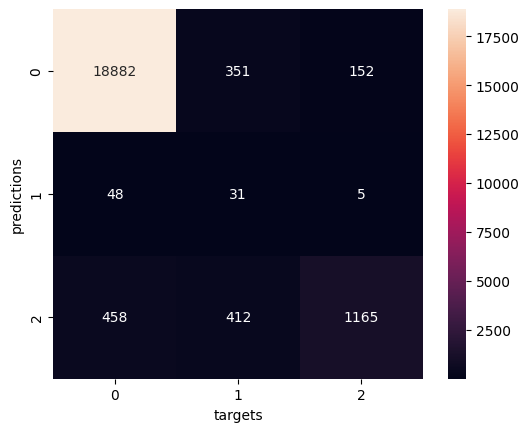

In [ ]:
sns.heatmap(all_predictions_train.groupby(['predictions','targets']).timestep.count().unstack(), annot=True, square=True, fmt='d')